# Check FGTV variables — raw output by strategy

Reads the **raw** WIDE_INPUTS_OUTPUTS file (pre-decomposition) of the latest run and
plots one chart per fgtv variable (from the `vars` column of the inventory targets),
with one line per strategy (mapped via `ATTRIBUTE_PRIMARY.csv`).
Initial value (year 2015) is highlighted.

In [8]:
import os, glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path(os.getcwd()).resolve()
while PROJECT_DIR.name != "ssp_libya" and PROJECT_DIR.parent != PROJECT_DIR:
    PROJECT_DIR = PROJECT_DIR.parent

RUN_ROOT = PROJECT_DIR / "ssp_modeling" / "ssp_run_output"
TARGETS_PATH = (
    PROJECT_DIR / "ssp_modeling" / "output_postprocessing" / "data" / "invent"
    / "emission_targets_lby_2023.csv"
)
YEAR_REF = 2023
TIME_PERIOD_REF = YEAR_REF - 2015

candidates = sorted(
    [Path(p) for p in glob.glob(str(RUN_ROOT / "sisepuede_results_*/sisepuede_results_*_WIDE_INPUTS_OUTPUTS.csv"))],
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
RAW_PATH = candidates[0]
RUN_DIR = RAW_PATH.parent
print(f"Using run: {RUN_DIR.name}")
print(f"Raw file:  {RAW_PATH.name}")

Using run: sisepuede_results_sisepuede_run_2026-04-30T19;53;16.980878
Raw file:  sisepuede_results_sisepuede_run_2026-04-30T19;53;16.980878_WIDE_INPUTS_OUTPUTS.csv


In [9]:
# Build the fgtv variable list grouped by (category, gas)
# Categories: dtp (= "Fugitive" in IPCC), venting, flaring  -- detected from the var name
te = pd.read_csv(TARGETS_PATH)
te_fgtv = te[te["subsector_ssp"] == "fgtv"][["ID", "gas", "vars"]]

CATEGORIES = ["dtp", "venting", "flaring"]

def category_of(var: str) -> str | None:
    for c in CATEGORIES:
        if f"_fgtv_{c}_" in var:
            return c
    return None

vars_by_cat_gas = {}  # (category, gas) -> list[(var, ID)]
seen = set()
for _, r in te_fgtv.iterrows():
    for v in r["vars"].split(":"):
        v = v.strip()
        if not v or v not in df.columns or v in seen:
            continue
        seen.add(v)
        cat = category_of(v)
        if cat is None:
            continue
        vars_by_cat_gas.setdefault((cat, r["gas"]), []).append((v, r["ID"]))

for (cat, gas), vs in vars_by_cat_gas.items():
    print(f"\n=== {cat} | {gas} ({len(vs)} vars) ===")
    for v, sid in vs:
        print(f"  [{sid}]  {v}")


=== dtp | CH4 (3 vars) ===
  [1.B - Fugitive emissions from fuels - Fugitive:CH4]  emission_co2e_ch4_fgtv_dtp_fuel_coal
  [1.B - Fugitive emissions from fuels - Fugitive:CH4]  emission_co2e_ch4_fgtv_dtp_fuel_crude
  [1.B - Fugitive emissions from fuels - Fugitive:CH4]  emission_co2e_ch4_fgtv_dtp_fuel_oil

=== dtp | CO2 (2 vars) ===
  [1.B - Fugitive emissions from fuels - Fugitive:CO2]  emission_co2e_co2_fgtv_dtp_fuel_coal
  [1.B - Fugitive emissions from fuels - Fugitive:CO2]  emission_co2e_co2_fgtv_dtp_fuel_crude

=== venting | CH4 (3 vars) ===
  [1.B - Fugitive emissions from fuels - Venting:CH4]  emission_co2e_ch4_fgtv_venting_fuel_coal
  [1.B - Fugitive emissions from fuels - Venting:CH4]  emission_co2e_ch4_fgtv_venting_fuel_crude
  [1.B - Fugitive emissions from fuels - Venting:CH4]  emission_co2e_ch4_fgtv_venting_fuel_oil

=== venting | CO2 (3 vars) ===
  [1.B - Fugitive emissions from fuels - Venting:CO2]  emission_co2e_co2_fgtv_venting_fuel_coal
  [1.B - Fugitive emissions fr

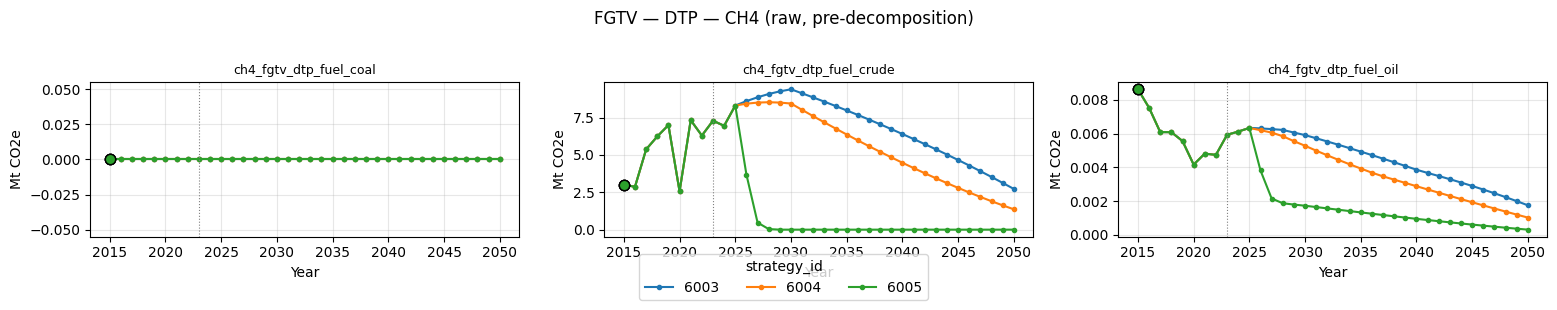

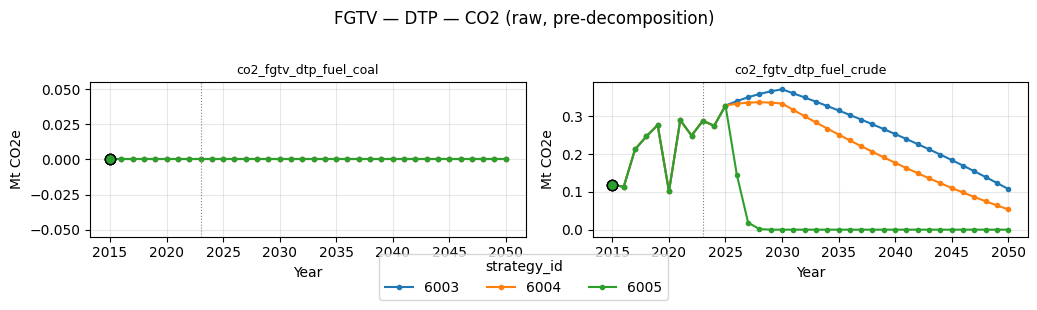

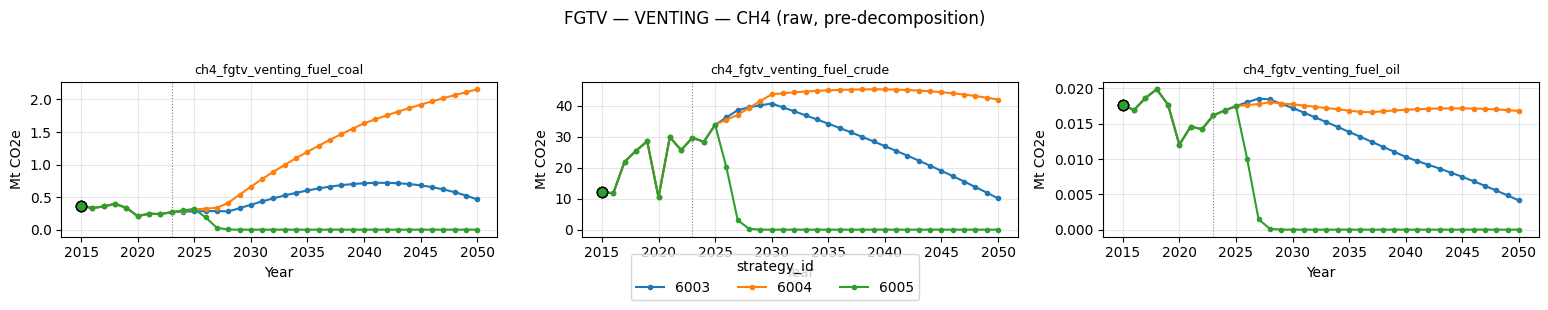

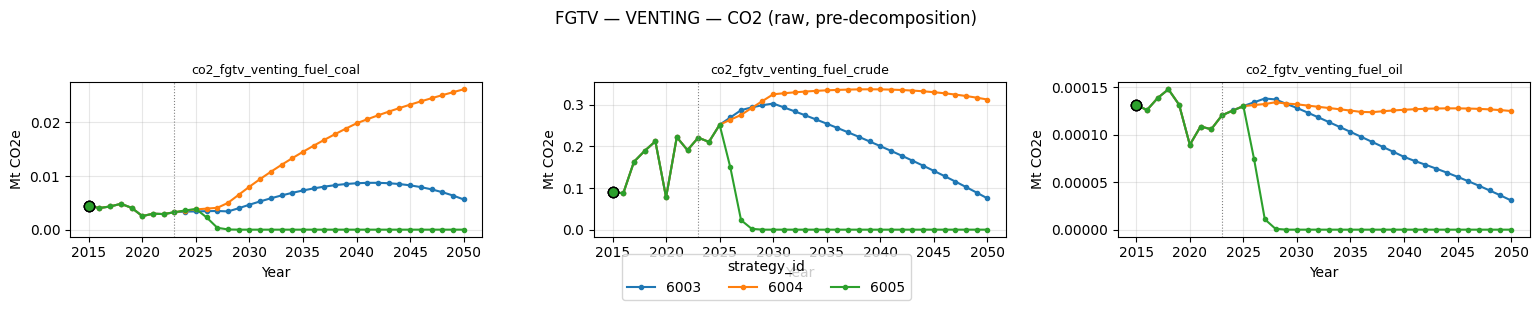

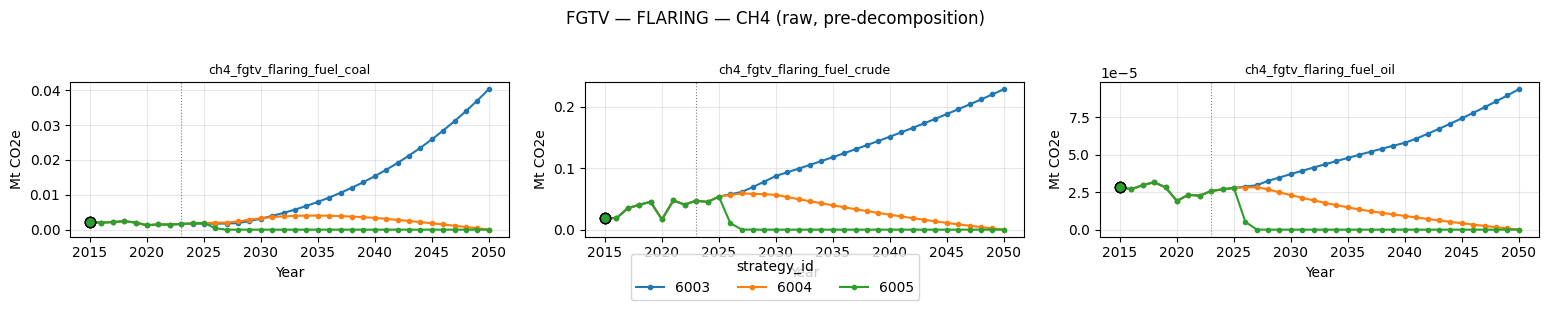

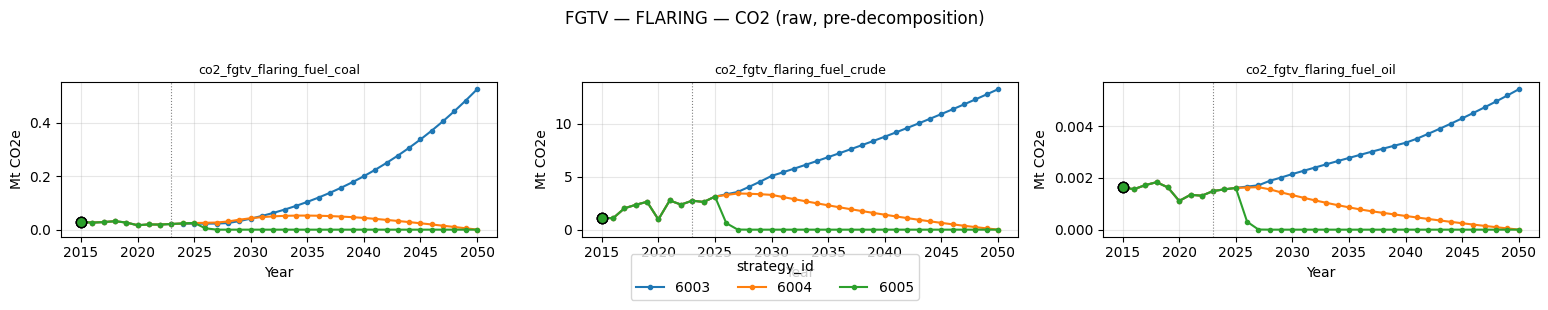

In [10]:
# One figure per (category x gas); one panel per variable; one line per strategy
strategies = sorted(df[strat_col].dropna().unique().tolist())
cmap = plt.get_cmap("tab10")
color_for = {s: cmap(i % 10) for i, s in enumerate(strategies)}

# Iterate in fixed order: dtp -> venting -> flaring, gases sorted
ordered_keys = sorted(vars_by_cat_gas.keys(), key=lambda k: (CATEGORIES.index(k[0]), k[1]))

for (cat, gas) in ordered_keys:
    var_list = vars_by_cat_gas[(cat, gas)]
    ncols = min(len(var_list), 3)
    nrows = int(np.ceil(len(var_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.0 * nrows), sharex=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, (var, sid) in zip(axes, var_list):
        for s in strategies:
            sub = df[df[strat_col] == s].sort_values("year")
            ax.plot(sub["year"], sub[var], marker="o", markersize=3, color=color_for[s], label=str(s))
            if not sub.empty:
                init = sub.iloc[0]
                ax.scatter([init["year"]], [init[var]], color=color_for[s], edgecolor="black", s=55, zorder=5)
        short = var.replace("emission_co2e_", "")
        ax.set_title(short, fontsize=9)
        ax.set_ylabel("Mt CO2e")
        ax.grid(True, alpha=0.3)
        ax.axvline(YEAR_REF, color="gray", linestyle=":", linewidth=0.8)

    for ax in axes[len(var_list):]:
        ax.set_visible(False)
    for ax in axes[-ncols:]:
        ax.set_xlabel("Year")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title=strat_col, loc="lower center",
               ncol=min(len(strategies), 6), bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(f"FGTV — {cat.upper()} — {gas} (raw, pre-decomposition)", fontsize=12)
    fig.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

In [11]:
# Initial values per (variable, strategy) at first year, split by (category, gas)
init_year = int(df["year"].min())
for (cat, gas) in ordered_keys:
    vs = [v for v, _ in vars_by_cat_gas[(cat, gas)]]
    tbl = (
        df[df["year"] == init_year]
        .groupby(strat_col)[vs]
        .first()
        .T
    )
    tbl.index.name = "variable"
    print(f"\n=== Initial values at year {init_year} — {cat.upper()} | {gas} ===")
    print(tbl.round(6).to_string())


=== Initial values at year 2015 — DTP | CH4 ===
strategy_id                                6003      6004      6005
variable                                                           
emission_co2e_ch4_fgtv_dtp_fuel_coal   0.000000  0.000000  0.000000
emission_co2e_ch4_fgtv_dtp_fuel_crude  2.997197  2.997197  2.997197
emission_co2e_ch4_fgtv_dtp_fuel_oil    0.008624  0.008624  0.008624

=== Initial values at year 2015 — DTP | CO2 ===
strategy_id                                6003      6004      6005
variable                                                           
emission_co2e_co2_fgtv_dtp_fuel_coal   0.000000  0.000000  0.000000
emission_co2e_co2_fgtv_dtp_fuel_crude  0.118685  0.118685  0.118685

=== Initial values at year 2015 — VENTING | CH4 ===
strategy_id                                     6003       6004       6005
variable                                                                  
emission_co2e_ch4_fgtv_venting_fuel_coal    0.361995   0.361995   0.361995
emission_co2

In [12]:
# Initial values per (variable, strategy) at year 2015
init_year = int(df["year"].min())
init_tbl = (
    df[df["year"] == init_year]
    .groupby(strat_col)[fgtv_vars]
    .first()
    .T
)
init_tbl.index.name = "variable"
print(f"Initial values at year {init_year}")
init_tbl.round(6)

NameError: name 'fgtv_vars' is not defined